In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
df_model = pd.read_csv("../data/interim/train_cleaned_v1.csv")

print("Shape:", df_model.shape)

df_model.head()

Shape: (149730, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
X = df_model.drop("SeriousDlqin2yrs", axis=1)
y = df_model["SeriousDlqin2yrs"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (149730, 10)
Target shape: (149730,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (119784, 10)
X_test : (29946, 10)
y_train: (119784,)
y_test : (29946,)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(119784, 10)
(29946, 10)


In [6]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = lr.predict(X_test_scaled)

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("First 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Default Probabilities:")
print(y_prob[:10])

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Default Probabilities:
[0.08306642 0.0470969  0.16022862 0.02624119 0.03253985 0.03696915
 0.03349922 0.02696419 0.03945449 0.10247797]


In [8]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9376878381085955


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27970
           1       0.62      0.14      0.23      1976

    accuracy                           0.94     29946
   macro avg       0.78      0.57      0.60     29946
weighted avg       0.92      0.94      0.92     29946



In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[27794   176]
 [ 1690   286]]


In [11]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8072457350197363


In [12]:
lr_balanced = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_balanced.fit(X_train_scaled, y_train)

print("Balanced Logistic Regression trained successfully!")

Balanced Logistic Regression trained successfully!


In [13]:
y_pred_bal = lr_balanced.predict(X_test_scaled)

y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

In [14]:
accuracy_bal = accuracy_score(y_test, y_pred_bal)

print("Accuracy:", accuracy_bal)

Accuracy: 0.8584785948039805


In [15]:
print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.97      0.88      0.92     27970
           1       0.26      0.61      0.36      1976

    accuracy                           0.86     29946
   macro avg       0.61      0.74      0.64     29946
weighted avg       0.92      0.86      0.88     29946



In [16]:
cm_bal = confusion_matrix(y_test, y_pred_bal)

print(cm_bal)

[[24500  3470]
 [  768  1208]]


In [17]:
roc_auc_bal = roc_auc_score(y_test, y_prob_bal)

print("ROC-AUC:", roc_auc_bal)

ROC-AUC: 0.813615341553052


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_pred_thresh = (y_prob_bal >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"\nThreshold: {threshold}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")


Threshold: 0.1
Precision: 0.066
Recall: 0.999
F1-score: 0.124

Threshold: 0.2
Precision: 0.075
Recall: 0.979
F1-score: 0.139

Threshold: 0.3
Precision: 0.101
Recall: 0.892
F1-score: 0.182

Threshold: 0.4
Precision: 0.153
Recall: 0.758
F1-score: 0.254

Threshold: 0.5
Precision: 0.258
Recall: 0.611
F1-score: 0.363


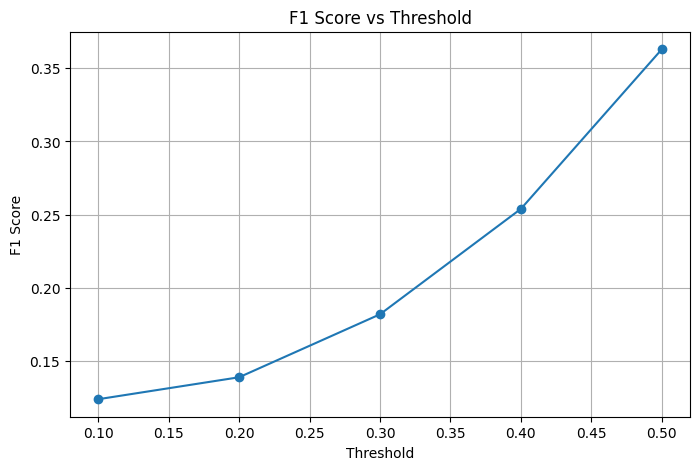

In [19]:
import matplotlib.pyplot as plt

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
f1_scores = [0.124, 0.139, 0.182, 0.254, 0.363]

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker='o')

plt.title("F1 Score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.grid(True)
plt.show()

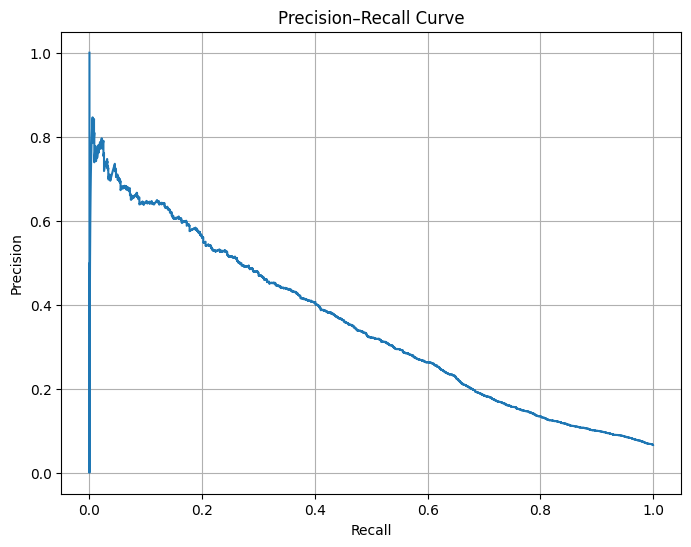

In [20]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob_bal
)

plt.figure(figsize=(8,6))

plt.plot(recalls, precisions)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")

plt.grid(True)

plt.show()

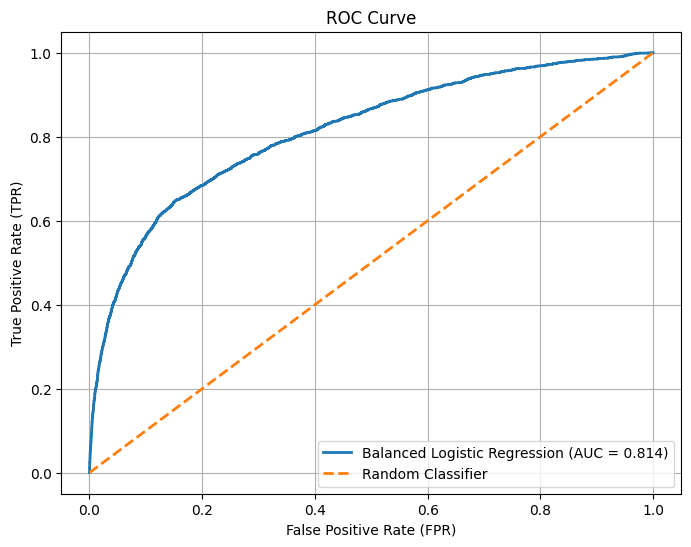

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_bal)

# Compute ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob_bal)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Balanced Logistic Regression (AUC = {roc_auc:.3f})'
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=2,
    label='Random Classifier'
)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

In [22]:
from imblearn.over_sampling import SMOTE

In [23]:
print("Original Training Distribution:")
print(y_train.value_counts())

Original Training Distribution:
SeriousDlqin2yrs
0    111881
1      7903
Name: count, dtype: int64


In [24]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
SeriousDlqin2yrs
0    111881
1    111881
Name: count, dtype: int64


In [25]:
lr_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

print("SMOTE Logistic Regression trained!")

SMOTE Logistic Regression trained!


In [26]:
y_pred_smote = lr_smote.predict(X_test_scaled)

y_prob_smote = lr_smote.predict_proba(X_test_scaled)[:,1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_smote))

Accuracy:
0.8500968409804315

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     27970
           1       0.25      0.62      0.35      1976

    accuracy                           0.85     29946
   macro avg       0.61      0.74      0.63     29946
weighted avg       0.92      0.85      0.88     29946


Confusion Matrix:
[[24233  3737]
 [  752  1224]]

ROC-AUC:
0.8122407122871671


In [28]:
import joblib

joblib.dump(lr, "../models/logistic_baseline.pkl")
joblib.dump(scaler, "../models/logistic_scaler.pkl")

print("Baseline Logistic Regression saved!")

Baseline Logistic Regression saved!


In [29]:
joblib.dump(
    lr_balanced,
    "../models/logistic_balanced.pkl"
)

print("Balanced Logistic Regression saved!")

Balanced Logistic Regression saved!


In [30]:
joblib.dump(
    lr_smote,
    "../models/logistic_smote.pkl"
)

print("SMOTE Logistic Regression saved!")

SMOTE Logistic Regression saved!


In [31]:
model_results = {
    "Baseline LR": {
        "Accuracy": 0.938,
        "Precision": 0.62,
        "Recall": 0.14,
        "F1": 0.23,
        "ROC_AUC": 0.807
    },

    "Balanced LR": {
        "Accuracy": 0.858,
        "Precision": 0.258,
        "Recall": 0.611,
        "F1": 0.363,
        "ROC_AUC": 0.814
    },

    "SMOTE LR": {
        "Accuracy": 0.850,
        "Precision": 0.247,
        "Recall": 0.619,
        "F1": 0.353,
        "ROC_AUC": 0.812
    }
}

In [32]:
results_df = pd.DataFrame(model_results).T

results_df

,Accuracy,Precision,Recall,F1,ROC_AUC
Baseline LR,0.938,0.620,0.140,0.230,0.807
Balanced LR,0.858,0.258,0.611,0.363,0.814
SMOTE LR,0.850,0.247,0.619,0.353,0.812


In [33]:
results_df.to_csv(
    "../models/model_leaderboard.csv"
)

print("Leaderboard saved!")

Leaderboard saved!
